In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

import joblib
import json
import os
import warnings

warnings.filterwarnings("ignore")

# Load feature-engineered dataset
df = pd.read_csv(
    "../data/processed/campaign_data_feature_engineered.csv"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (10000, 45)


,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,...,CPC,conversion_rate,CPA,ROAS,profit,start_year,start_month,start_day,start_week,creative_to_campaign_age_ratio
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,...,2.23,0.498,448.23,0.32,-606.79,2024,3,6,10,2.117647
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,...,2.48,1.071,231.63,1.49,570.04,2024,1,26,4,2.818182
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,...,3.88,5.357,72.43,6.68,2468.70,2025,5,15,20,2.468750
3,CAMP_00004,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,...,8.29,2.439,339.89,0.49,-517.39,2024,7,21,29,1.781250
4,CAMP_00005,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,...,1.41,0.000,0.00,0.00,-425.82,2025,3,9,10,0.326923


In [2]:
# Define the same 15 features used in the other models

categorical_features_profit = [
    "campaign_objective",
    "platform",
    "device_type",
    "creative_format",
    "ad_copy_length",
    "income_bracket",
    "purchase_intent_score",
    "day_of_week",
    "industry_vertical"
]

numerical_features_profit = [
    "has_call_to_action",
    "retargeting_flag",
    "quarter",
    "campaign_day",
    "quality_score",
    "ad_spend"
]

model_features_profit = (
    categorical_features_profit + numerical_features_profit
)

# Create input features
X_profit = df[model_features_profit].copy()

# Create binary target
y_profit = (df["profit"] > 0).astype(int)

# Ensure binary features are integers
X_profit["has_call_to_action"] = (
    X_profit["has_call_to_action"].astype(int)
)

X_profit["retargeting_flag"] = (
    X_profit["retargeting_flag"].astype(int)
)

# Display target distribution
print("Profitability Classification Setup")
print("-" * 40)

print("Number of features:", len(model_features_profit))
print("Categorical features:", len(categorical_features_profit))
print("Numerical features:", len(numerical_features_profit))
print("Total samples:", len(X_profit))

print("\nTarget Distribution:")
print("Profitable (1):", (y_profit == 1).sum())
print("Loss-making (0):", (y_profit == 0).sum())

print("\nTarget Percentage:")
print(
    "Profitable:",
    round((y_profit == 1).mean() * 100, 2),
    "%"
)

print(
    "Loss-making:",
    round((y_profit == 0).mean() * 100, 2),
    "%"
)

Profitability Classification Setup
----------------------------------------
Number of features: 15
Categorical features: 9
Numerical features: 6
Total samples: 10000

Target Distribution:
Profitable (1): 7831
Loss-making (0): 2169

Target Percentage:
Profitable: 78.31 %
Loss-making: 21.69 %


In [3]:
# Train-test split
X_train_profit, X_test_profit, y_train_profit, y_test_profit = train_test_split(
    X_profit,
    y_profit,
    test_size=0.20,
    random_state=42,
    stratify=y_profit
)

# Preprocessing
preprocessor_profit = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_profit
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features_profit
        )
    ]
)

# Fit preprocessing only on training data
X_train_profit_processed = preprocessor_profit.fit_transform(
    X_train_profit
)

X_test_profit_processed = preprocessor_profit.transform(
    X_test_profit
)

print("Train/Test Split & Preprocessing")
print("-" * 40)

print("Training samples:", len(X_train_profit))
print("Testing samples :", len(X_test_profit))

print(
    "Processed training shape:",
    X_train_profit_processed.shape
)

print(
    "Processed testing shape :",
    X_test_profit_processed.shape
)

print("\nTraining class distribution:")
print(y_train_profit.value_counts())

print("\nTesting class distribution:")
print(y_test_profit.value_counts())

Train/Test Split & Preprocessing
----------------------------------------
Training samples: 8000
Testing samples : 2000
Processed training shape: (8000, 49)
Processed testing shape : (2000, 49)

Training class distribution:
profit
1    6265
0    1735
Name: count, dtype: int64

Testing class distribution:
profit
1    1566
0     434
Name: count, dtype: int64


In [4]:
# Define baseline classification models

models_profit = {
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    
    "HistGradient Boosting": HistGradientBoostingClassifier(
        random_state=42
    )
}

results_profit = []
trained_models_profit = {}

# Train and evaluate each model
for name, model in models_profit.items():

    model.fit(
        X_train_profit_processed,
        y_train_profit
    )

    y_pred = model.predict(
        X_test_profit_processed
    )

    y_prob = model.predict_proba(
        X_test_profit_processed
    )[:, 1]

    accuracy = accuracy_score(
        y_test_profit,
        y_pred
    )

    precision = precision_score(
        y_test_profit,
        y_pred
    )

    recall = recall_score(
        y_test_profit,
        y_pred
    )

    f1 = f1_score(
        y_test_profit,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test_profit,
        y_prob
    )

    results_profit.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    trained_models_profit[name] = model


# Create comparison table
results_profit_df = (
    pd.DataFrame(results_profit)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

print("Baseline Profitability Classification Results")
print("-" * 55)

print(
    results_profit_df.round(4)
)

Baseline Profitability Classification Results
-------------------------------------------------------
                   Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  HistGradient Boosting    0.8755     0.8927  0.9559    0.9232   0.9230
1      Gradient Boosting    0.8650     0.8720  0.9700    0.9184   0.9192
2          Random Forest    0.8565     0.8636  0.9700    0.9137   0.9026
3            Extra Trees    0.8500     0.8634  0.9604    0.9093   0.8826


In [5]:
# Select the best baseline model

best_profit_model_name = results_profit_df.iloc[0]["Model"]

best_profit_model = trained_models_profit[
    best_profit_model_name
]

# Predictions
y_pred_profit = best_profit_model.predict(
    X_test_profit_processed
)

# Probability of being profitable
y_prob_profit = best_profit_model.predict_proba(
    X_test_profit_processed
)[:, 1]

# Final metrics
accuracy_profit = accuracy_score(
    y_test_profit,
    y_pred_profit
)

precision_profit = precision_score(
    y_test_profit,
    y_pred_profit
)

recall_profit = recall_score(
    y_test_profit,
    y_pred_profit
)

f1_profit = f1_score(
    y_test_profit,
    y_pred_profit
)

roc_auc_profit = roc_auc_score(
    y_test_profit,
    y_prob_profit
)

print("Best Profitability Model")
print("-" * 40)
print("Model:", best_profit_model_name)
print(f"Accuracy : {accuracy_profit:.4f}")
print(f"Precision: {precision_profit:.4f}")
print(f"Recall   : {recall_profit:.4f}")
print(f"F1-Score : {f1_profit:.4f}")
print(f"ROC-AUC  : {roc_auc_profit:.4f}")

print("\nProbability Range")
print("-" * 40)
print(
    "Minimum probability:",
    round(y_prob_profit.min(), 4)
)
print(
    "Maximum probability:",
    round(y_prob_profit.max(), 4)
)

Best Profitability Model
----------------------------------------
Model: HistGradient Boosting
Accuracy : 0.8755
Precision: 0.8927
Recall   : 0.9559
F1-Score : 0.9232
ROC-AUC  : 0.9230

Probability Range
----------------------------------------
Minimum probability: 0.0048
Maximum probability: 0.9993


Confusion Matrix
----------------------------------------
[[ 254  180]
 [  69 1497]]


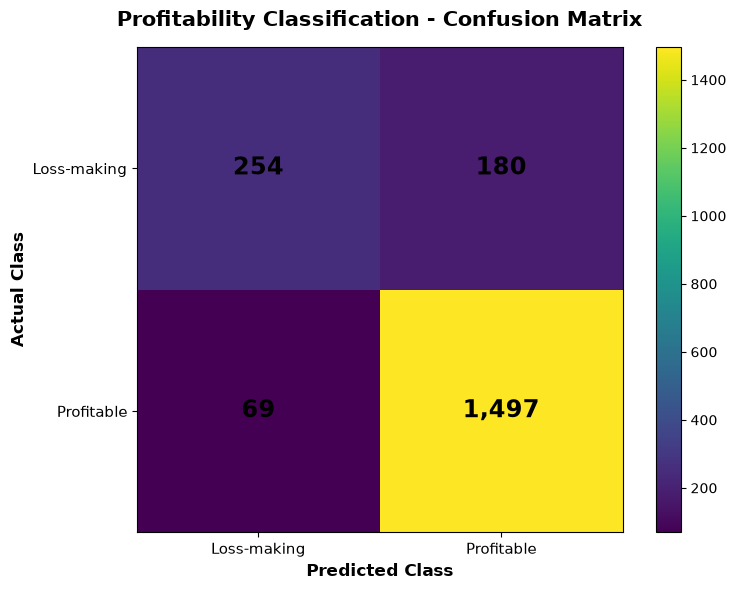

In [6]:
# Confusion Matrix

cm_profit = confusion_matrix(
    y_test_profit,
    y_pred_profit
)

print("Confusion Matrix")
print("-" * 40)
print(cm_profit)

# --------------------------------------------------
# Visualize Confusion Matrix
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.imshow(cm_profit)

plt.title(
    "Profitability Classification - Confusion Matrix",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Predicted Class",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Actual Class",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    [0, 1],
    ["Loss-making", "Profitable"],
    fontsize=11
)

plt.yticks(
    [0, 1],
    ["Loss-making", "Profitable"],
    fontsize=11
)

# Add values
for i in range(cm_profit.shape[0]):
    for j in range(cm_profit.shape[1]):

        plt.text(
            j,
            i,
            f"{cm_profit[i, j]:,}",
            ha="center",
            va="center",
            fontsize=17,
            fontweight="bold"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

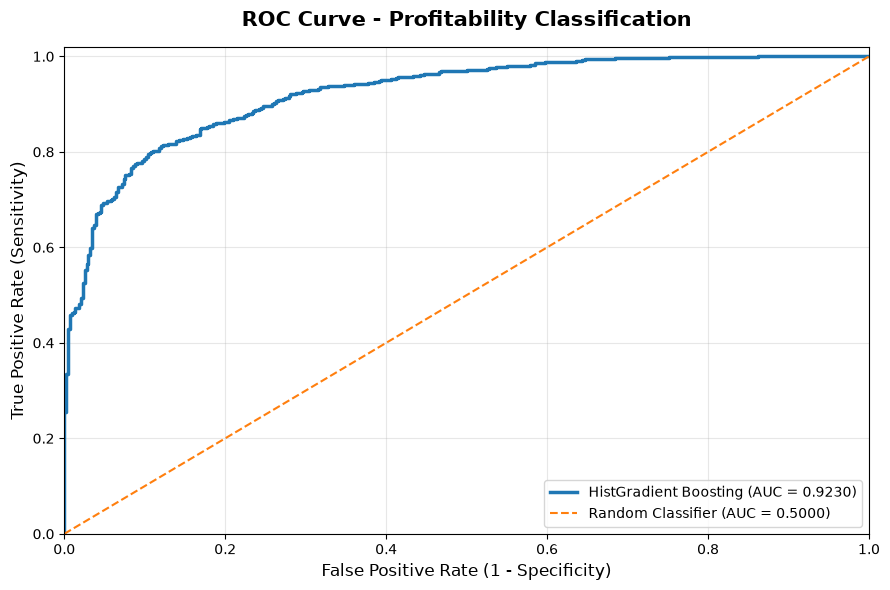

ROC-AUC Score: 0.9230


In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr_profit, tpr_profit, thresholds_profit = roc_curve(
    y_test_profit,
    y_prob_profit
)

# Calculate ROC-AUC
roc_auc_profit = roc_auc_score(
    y_test_profit,
    y_prob_profit
)

# --------------------------------------------------
# Plot ROC Curve
# --------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_profit,
    tpr_profit,
    linewidth=2.5,
    label=f"HistGradient Boosting (AUC = {roc_auc_profit:.4f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier (AUC = 0.5000)"
)

plt.xlabel(
    "False Positive Rate (1 - Specificity)",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate (Sensitivity)",
    fontsize=12
)

plt.title(
    "ROC Curve - Profitability Classification",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.grid(
    alpha=0.3
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc_profit:.4f}")

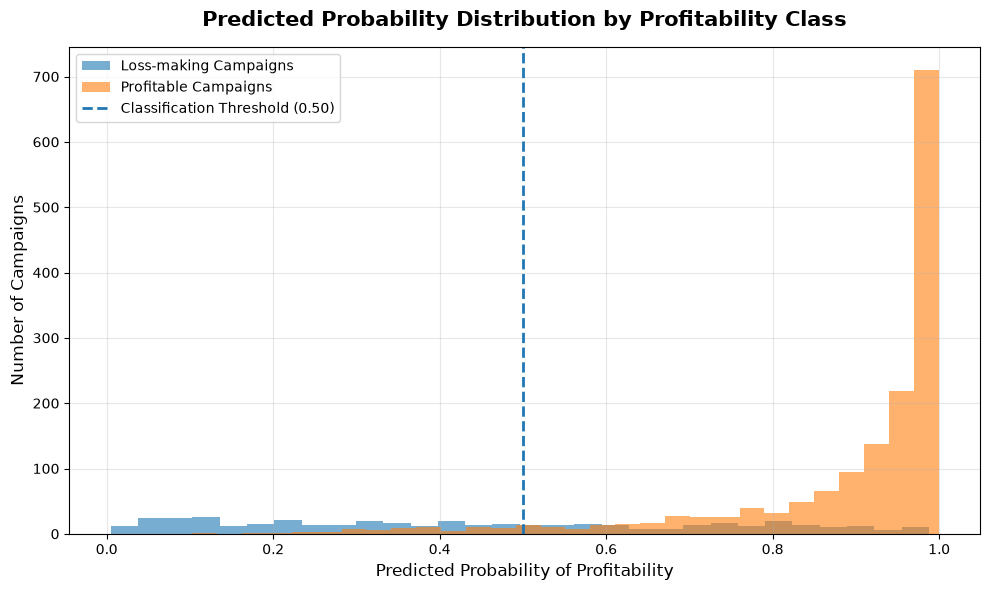

In [8]:
# Profitability Probability Distribution

plt.figure(figsize=(10, 6))

plt.hist(
    y_prob_profit[y_test_profit == 0],
    bins=30,
    alpha=0.6,
    label="Loss-making Campaigns"
)

plt.hist(
    y_prob_profit[y_test_profit == 1],
    bins=30,
    alpha=0.6,
    label="Profitable Campaigns"
)

plt.axvline(
    0.50,
    linestyle="--",
    linewidth=2,
    label="Classification Threshold (0.50)"
)

plt.xlabel(
    "Predicted Probability of Profitability",
    fontsize=12
)

plt.ylabel(
    "Number of Campaigns",
    fontsize=12
)

plt.title(
    "Predicted Probability Distribution by Profitability Class",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_importance_profit = permutation_importance(
    best_profit_model,
    X_test_profit_processed,
    y_test_profit,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

# Get processed feature names
feature_names_profit = (
    preprocessor_profit
    .get_feature_names_out()
)

# Create importance dataframe
importance_profit_df = pd.DataFrame({
    "Processed Feature": feature_names_profit,
    "Importance": perm_importance_profit.importances_mean
})

# --------------------------------------------------
# Map processed features to original features
# --------------------------------------------------

def get_original_feature_profit(feature_name):

    feature_name = feature_name.replace(
        "categorical__",
        ""
    ).replace(
        "numerical__",
        ""
    )

    for feature in model_features_profit:

        if feature_name == feature:
            return feature

        if feature_name.startswith(feature + "_"):
            return feature

    return feature_name


importance_profit_df[
    "Original Feature"
] = importance_profit_df[
    "Processed Feature"
].apply(get_original_feature_profit)

# --------------------------------------------------
# Aggregate importance
# --------------------------------------------------

aggregated_importance_profit = (
    importance_profit_df
    .groupby("Original Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Display results
print("Profitability Model - Feature Importance")
print("-" * 50)

aggregated_importance_profit.round(4)

Profitability Model - Feature Importance
--------------------------------------------------


,Original Feature,Importance
0,purchase_intent_score,0.0473
1,industry_vertical,0.0470
2,platform,0.0468
3,device_type,0.0430
4,campaign_objective,0.0308
5,day_of_week,0.0197
6,quarter,0.0190
7,ad_spend,0.0190
8,income_bracket,0.0152
9,retargeting_flag,0.0131


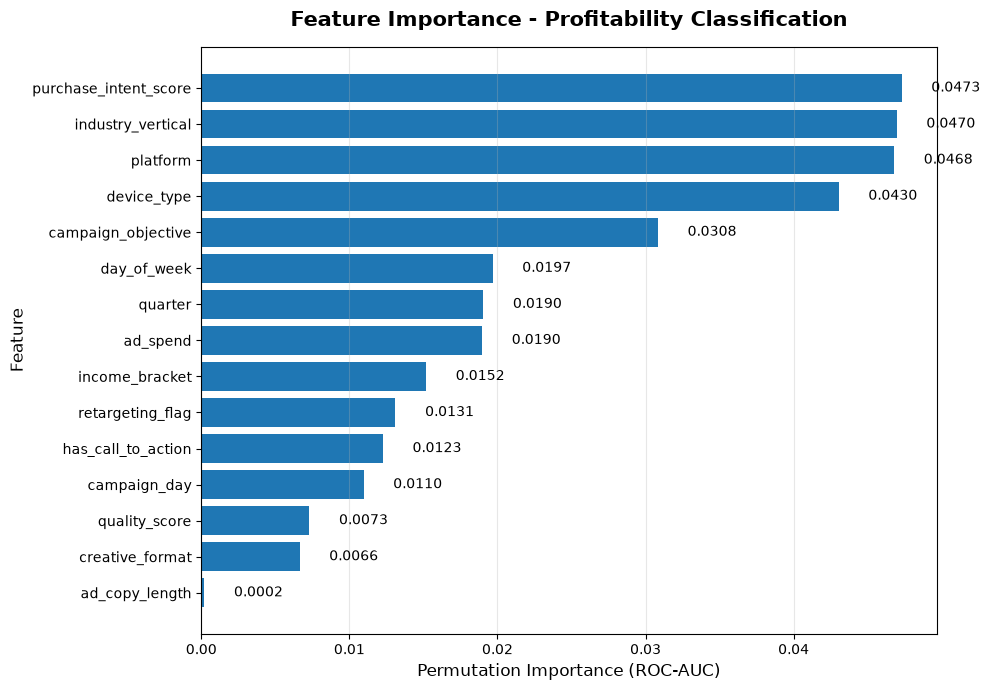

In [10]:
# Sort feature importance for plotting
plot_importance_profit = (
    aggregated_importance_profit
    .sort_values("Importance", ascending=True)
)

# Create horizontal bar chart
plt.figure(figsize=(10, 7))

bars = plt.barh(
    plot_importance_profit["Original Feature"],
    plot_importance_profit["Importance"]
)

plt.xlabel(
    "Permutation Importance (ROC-AUC)",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.title(
    "Feature Importance - Profitability Classification",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Add exact values to bars
for bar in bars:

    value = bar.get_width()

    plt.text(
        value + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        fontsize=10
    )

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [11]:
# Create complete profitability classification pipeline

profit_pipeline = Pipeline([
    ("preprocessor", preprocessor_profit),
    ("model", best_profit_model)
])

# Fit the complete pipeline on training data
profit_pipeline.fit(
    X_train_profit,
    y_train_profit
)

# Verify pipeline predictions
test_predictions_profit = profit_pipeline.predict(
    X_test_profit
)

test_probabilities_profit = profit_pipeline.predict_proba(
    X_test_profit
)[:, 1]

print("Profitability pipeline fitted successfully.")
print("Number of predictions:", len(test_predictions_profit))
print(
    "Minimum probability:",
    round(test_probabilities_profit.min(), 4)
)
print(
    "Maximum probability:",
    round(test_probabilities_profit.max(), 4)
)

# --------------------------------------------------
# Save model
# --------------------------------------------------

joblib.dump(
    profit_pipeline,
    "../models/profitability_best_model.pkl"
)

# --------------------------------------------------
# Save feature importance
# --------------------------------------------------

aggregated_importance_profit.to_csv(
    "../models/profitability_feature_importance.csv",
    index=False
)

# --------------------------------------------------
# Save model configuration
# --------------------------------------------------

profit_model_config = {
    "model": best_profit_model_name,
    "target": "profit",
    "target_type": "binary_classification",
    "classes": {
        "0": "Loss-making",
        "1": "Profitable"
    },
    "features": model_features_profit,
    "categorical_features": categorical_features_profit,
    "numerical_features": numerical_features_profit,
    "test_size": 0.20,
    "random_state": 42,
    "classification_threshold": 0.50,
    "accuracy": float(accuracy_profit),
    "precision": float(precision_profit),
    "recall": float(recall_profit),
    "f1_score": float(f1_profit),
    "roc_auc": float(roc_auc_profit)
}

with open(
    "../models/profitability_model_config.json",
    "w"
) as f:
    json.dump(
        profit_model_config,
        f,
        indent=4
    )

print("\nFiles saved successfully:")
print("../models/profitability_best_model.pkl")
print("../models/profitability_feature_importance.csv")
print("../models/profitability_model_config.json")

Profitability pipeline fitted successfully.
Number of predictions: 2000
Minimum probability: 0.0048
Maximum probability: 0.9993

Files saved successfully:
../models/profitability_best_model.pkl
../models/profitability_feature_importance.csv
../models/profitability_model_config.json


In [12]:
# Load the saved profitability model

loaded_profit_model = joblib.load(
    "../models/profitability_best_model.pkl"
)

# Generate predictions using the loaded pipeline
y_pred_profit_loaded = loaded_profit_model.predict(
    X_test_profit
)

# Generate profitability probabilities
y_prob_profit_loaded = (
    loaded_profit_model
    .predict_proba(X_test_profit)[:, 1]
)

# --------------------------------------------------
# Compare predictions
# --------------------------------------------------

prediction_difference_profit = np.abs(
    y_pred_profit - y_pred_profit_loaded
)

probability_difference_profit = np.abs(
    y_prob_profit - y_prob_profit_loaded
)

print("Saved Profitability Model Verification")
print("-" * 55)

print("Model loaded successfully.")

print(
    "Number of predictions:",
    len(y_pred_profit_loaded)
)

print(
    "Different class predictions:",
    np.sum(y_pred_profit != y_pred_profit_loaded)
)

print(
    "Maximum probability difference:",
    probability_difference_profit.max()
)

print(
    "Average probability difference:",
    probability_difference_profit.mean()
)

print(
    "Minimum loaded probability:",
    y_prob_profit_loaded.min()
)

print(
    "Maximum loaded probability:",
    y_prob_profit_loaded.max()
)

Saved Profitability Model Verification
-------------------------------------------------------
Model loaded successfully.
Number of predictions: 2000
Different class predictions: 0
Maximum probability difference: 0.0
Average probability difference: 0.0
Minimum loaded probability: 0.004792617025475493
Maximum loaded probability: 0.999338078182474


# Profitability Classification Model

## Objective

The objective of the Profitability Classification model is to predict whether a marketing campaign will be **profitable or loss-making**.

Instead of predicting the exact profit amount, the problem was formulated as a **binary classification task**. The model can also provide the **probability that a campaign will be profitable**.

### Target Definition

The existing `profit` variable was converted into a binary target:

- **1 → Profitable:** `profit > 0`
- **0 → Loss-making:** `profit <= 0`

Negative profit values were retained because they represent genuine loss-making campaigns.

---

## Feature Selection

The same **15 features** used in the Revenue, CTR, and Conversion Rate models were retained for consistency.

### Categorical Features

- `campaign_objective`
- `platform`
- `device_type`
- `creative_format`
- `ad_copy_length`
- `income_bracket`
- `purchase_intent_score`
- `day_of_week`
- `industry_vertical`

### Numerical Features

- `has_call_to_action`
- `retargeting_flag`
- `quarter`
- `campaign_day`
- `quality_score`
- `ad_spend`

Categorical variables were encoded using **One-Hot Encoding**, while numerical variables were standardized using **StandardScaler**.

The preprocessing resulted in **49 processed features**.

---

## Target Distribution

The dataset contains **10,000 campaigns**.

| Class | Count | Percentage |
|---|---:|---:|
| Profitable | 7,831 | 78.31% |
| Loss-making | 2,169 | 21.69% |

A **stratified 80:20 train-test split** was used.

- Training samples: **8,000**
- Testing samples: **2,000**

---

## Baseline Model Comparison

Four classification algorithms were evaluated:

- Gradient Boosting
- Random Forest
- Extra Trees
- HistGradient Boosting

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| **HistGradient Boosting** | **0.8755** | **0.8927** | **0.9559** | **0.9232** | **0.9230** |
| Gradient Boosting | 0.8650 | 0.8720 | 0.9700 | 0.9184 | 0.9192 |
| Random Forest | 0.8565 | 0.8636 | 0.9700 | 0.9137 | 0.9026 |
| Extra Trees | 0.8500 | 0.8634 | 0.9604 | 0.9093 | 0.8826 |

**HistGradient Boosting** was selected as the final model because it achieved the highest Accuracy, Precision, F1-Score, and ROC-AUC.

---

## Final Model Performance

The final HistGradient Boosting model achieved:

- **Accuracy:** 87.55%
- **Precision:** 89.27%
- **Recall:** 95.59%
- **F1-Score:** 92.32%
- **ROC-AUC:** 0.9230

The default **0.50 classification threshold** was retained because it provided a better overall balance across the evaluation metrics.

---

## Confusion Matrix

Using the default 0.50 threshold:

| Actual / Predicted | Loss-making | Profitable |
|---|---:|---:|
| **Loss-making** | 254 | 180 |
| **Profitable** | 69 | 1,497 |

The model correctly identified **1,497 profitable campaigns** and **254 loss-making campaigns** from the 2,000 test campaigns.

---

## ROC-AUC Analysis

The ROC curve demonstrated strong separation between profitable and loss-making campaigns.

The model achieved a **ROC-AUC of 0.9230**, indicating excellent classification performance and a strong ability to distinguish between the two profitability classes.

---

## Profitability Probability

The model uses `predict_proba()` to provide a probability of profitability for each campaign.

The predicted probability range was approximately:

**0.48% to 99.93%**

This allows the recommendation system to provide outputs such as:

> **Probability of Profitability: 94.6%**

rather than only providing a binary prediction.

---

## Feature Importance

Permutation importance based on ROC-AUC identified the following influential features:

| Feature | Importance |
|---|---:|
| `purchase_intent_score` | 0.0473 |
| `industry_vertical` | 0.0470 |
| `platform` | 0.0468 |
| `device_type` | 0.0430 |
| `campaign_objective` | 0.0308 |
| `day_of_week` | 0.0197 |
| `quarter` | 0.0190 |
| `ad_spend` | 0.0190 |
| `income_bracket` | 0.0152 |
| `retargeting_flag` | 0.0131 |
| `has_call_to_action` | 0.0123 |
| `campaign_day` | 0.0110 |
| `quality_score` | 0.0073 |
| `creative_format` | 0.0066 |
| `ad_copy_length` | 0.0002 |

The most influential features were **purchase intent score, industry vertical, platform, and device type**.

---

## Model Saving and Verification

The complete preprocessing and classification pipeline was saved as:

```text
../models/profitability_best_model.pkl